# PageRank and Random Walks on Graphs

PageRank is the stationary distribution of
$$
\pi = \alpha P^\top \pi + (1-\alpha) v,
$$
where teleportation vector $v$ guarantees ergodicity. We study ranking changes with $\alpha$.

PageRank is the stationary law of a random walk with teleportation,
$$p=\alpha P^\top p+(1-\alpha)v.$$
Teleportation guarantees a unique stable solution and controls how strongly graph links dominate the personalization vector. Iteration curves and graph views connect centrality to probability flow.

We check the fixed-point residual as well as the visual ranking. This ensures that apparent centrality differences reflect the stationary equation rather than insufficient power iterations.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/pagerank-random-walks/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/pagerank-random-walks") if Path("python/pagerank-random-walks").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **PageRank and Random Walks on Graphs**, with equations and plots designed to expose both the model and the numerical behavior.


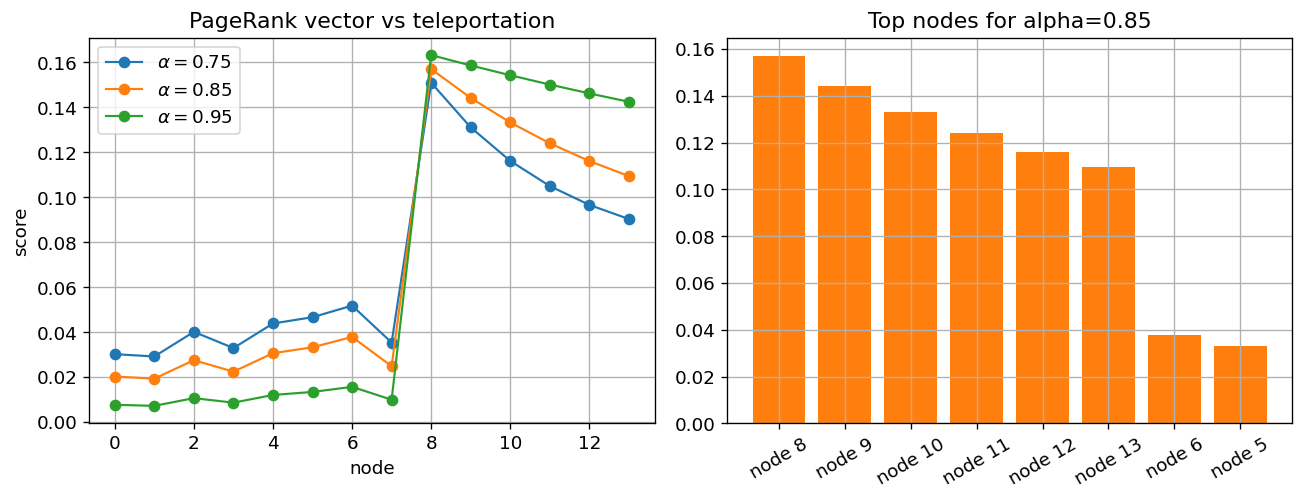

In [2]:
n = 14
A = np.zeros((n, n))
edges = [
    (0,1),(0,2),(1,2),(1,4),(2,3),(2,4),(3,0),(3,5),(4,5),(4,6),
    (5,6),(5,7),(6,8),(7,8),(8,9),(9,10),(10,11),(11,12),(12,13),(13,8)
]
for i, j in edges:
    A[i, j] = 1
out = A.sum(axis=1)
P = np.zeros_like(A)
for i in range(n):
    if out[i] > 0:
        P[i] = A[i] / out[i]
    else:
        P[i] = np.ones(n) / n

v = np.ones(n) / n
alphas = [0.75, 0.85, 0.95]
ranks = []
for a in alphas:
    pi = np.ones(n) / n
    for _ in range(200):
        pi = a * (P.T @ pi) + (1-a) * v
    pi /= pi.sum()
    ranks.append(pi)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for a, pi in zip(alphas, ranks):
    axes[0].plot(pi, marker="o", lw=1.3, label=fr"$\alpha={a}$")
axes[0].set_title("PageRank vector vs teleportation")
axes[0].set_xlabel("node")
axes[0].set_ylabel("score")
axes[0].legend()

top = np.argsort(ranks[1])[::-1][:8]
axes[1].bar(np.arange(len(top)), ranks[1][top], color="tab:orange")
axes[1].set_xticks(np.arange(len(top)))
axes[1].set_xticklabels([f"node {i}" for i in top], rotation=30)
axes[1].set_title("Top nodes for alpha=0.85")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- S. Brin, L. Page, "The Anatomy of a Large-Scale Hypertextual Web Search Engine", 1998.
- A. N. Langville, C. D. Meyer, *Google's PageRank and Beyond*, Princeton Univ. Press, 2006.
- D. F. Gleich, "PageRank Beyond the Web", SIAM Review, 2015.
